# XP GOLD

 # Society's assumptions aren't always true... aren't they?




We begin by loading the libraries needed for this project.

In [1]:
import importlib
import sys
import matplotlib


def install_and_import(packages):
    """
    Attempts to import packages. If a package is missing, it prints a message instead of installing.
    """
    for package in packages:
        try:
            globals()[package] = importlib.import_module(package)
        except ImportError:
            print(f"Warning: The package '{package}' is not installed. Please install it manually.")


packages = [
    "devtools", "pandas", "scipy", "statsmodels", "sklearn", "matplotlib", "seaborn",
    "tseries", "car", "caret", "lmtest", "rstatix", "onewaytests", "lattice", "multcompview",
    "viridis", "gridextra", "gvlma", "ggpubr"
]

install_and_import(packages)

# Now all available libraries are imported


In [2]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Now we can load the dataset

In [3]:
df = pd.read_csv('Students Performance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

### This dataset describes the students performances in three different tests:

- **Math**

- **Reading**

- **Writing**

### Through different variables:

- **gender** : binary sex at birth for each individual

- **race.ethnicity** : ethnicity group

- **parental.level.of.education** : formal level of education achieved by the individual

- **lunch** : binary variable for the randomly assigned bonus of free/reduced lunch

- **test.preparation.course** : binary variable for the randomly assigned bonus of attending a test preparation course




# Which 'gender' is better at maths? And which is better in writing and reading?

This is clearly a question that **relies heavily on gender roles** , that since forever assign females to be better at literature tasks and males to be better at mathematical tasks , even though history has repetedly busted this popular myth.

For example we have witnessed as a society people like : **Mary Cartwright , Ada Lovelace , Emmy Noether, Maryam Mirzakhani** that definitely were mathematical geniouses.

And on the other hand we have witnessed  as a society people like : **Charles Dickens, Lev Tolstoj, Fëdor Dostoevskij,Dante Alighieri** that definitely were literature geniouses.

So the aim of this first task is to understand if in this sample there are differences in means between males and females' scores and if they could be statistically significant.

### Before conducting any test , let's visualize the situation

We're going to do some data wrangling to visualize the scores by gender

In [7]:
new_df = df.melt(id_vars=['gender'], value_vars=['math score', 'reading score', 'writing score'], var_name='subject', value_name='score')

### Now we can finally plot the differences between genders in the scores


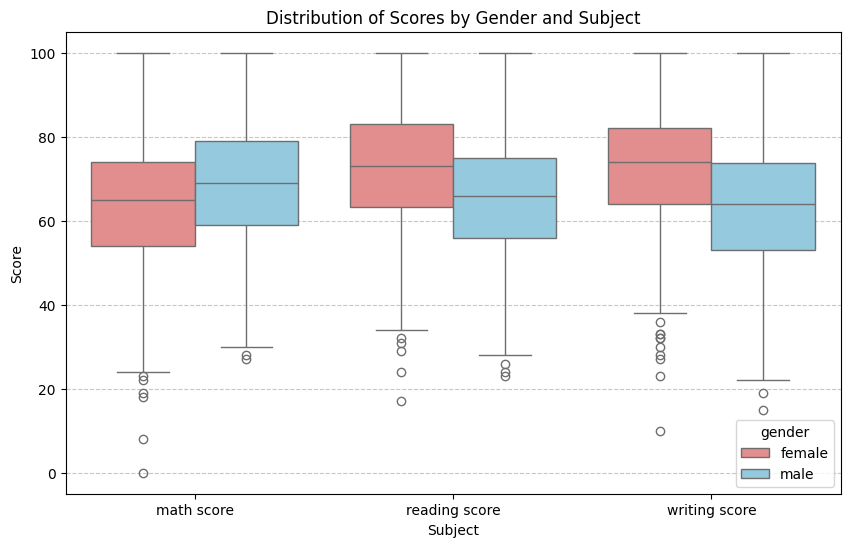

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=new_df, x='subject', y='score', hue='gender', palette={'male': 'skyblue', 'female': 'lightcoral'})
plt.title('Distribution of Scores by Gender and Subject')
plt.xlabel('Subject')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

It looks like:

- **For math score**: males are a little bit better

- **For reading score**: females are a little bit better

- **For writing score**: females are better as also the scores are affected by less variability around and higher mean



***



# Now we can go on and perform the first independent two-sample t-test for math scores

The size of the males and females samples are different!

This means that in the equation for the t statistic:

$$ t = \frac{\bar{x_{1}}-\bar{x_{2}}}{S_{pool}\sqrt{\frac{1}{n_{1}}-\frac{1}{n_{2}}}} $$
happens that:

$$n_{1}\neq n_{2}$$


First we perform some data wrangling on the main dataframe

In [9]:
# Create a new column 'treatment' based on 'lunch' and 'test preparation course'
df['treatment'] = df.apply(lambda row: f"{row['lunch'].replace(' ', '_')}_{row['test preparation course'].replace(' ', '_')}", axis=1)

# Create a tidy DataFrame for ANOVA with math scores and the new 'treatment' column
tidy_df_anova = df[['treatment', 'math score']].copy()

display(tidy_df_anova.head())

,treatment,math score
0,standard_none,72
1,standard_completed,69
2,standard_none,90
3,free/reduced_none,47
4,standard_none,76


In [10]:
Males_Math = df[df['gender'] == 'male']['math score']
Females_Math = df[df['gender'] == 'female']['math score']

print(f"Number of male students: {len(Males_Math)}")
print(f"Number of female students: {len(Females_Math)}")

Number of male students: 482
Number of female students: 518



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's start with a qqplot

<Figure size 800x640 with 0 Axes>

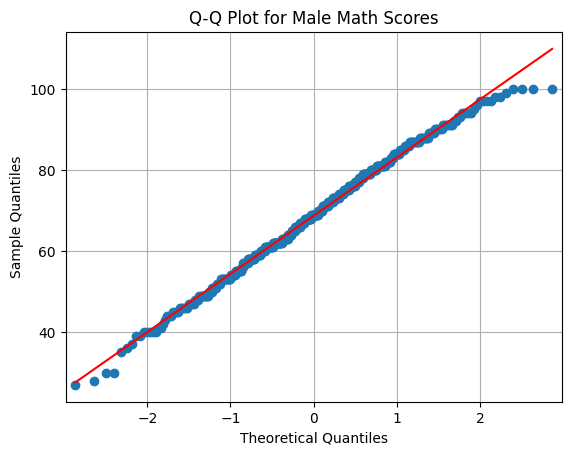

In [11]:
## TODO: Create a plot for the male math scores.
plt.figure(figsize=(10, 8), dpi = 80)
sm.qqplot(Males_Math, line='s')
plt.title('Q-Q Plot for Male Math Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)
plt.show()


</br>
</br>
</br>

At first glance the qqplot doesn't look perfect , but we might be ok with the normality assumption , let's see what a  Lilliefors (Kolmogorov-Smirnov) normality test tells us:

Hypothèse nulle (H₀) : L'échantillon provient d'une population qui suit une loi normale.

Hypothèse alternative (H₁) : L'échantillon ne provient pas d'une population qui suit une loi normale.

In [12]:
## TODO: Perform a Lilliefors (Kolmogorov-Smirnov) test for normality on the male math scores.
kstat, p_value = stats.kstest(Males_Math, 'norm')
print(f"K-statistic: {kstat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Rejet de l'hypothèse nulle")
    print("Les données ne suivent pas une distribution normale.")
else:
    print("Acceptation de l'hypothèse nulle")
    print("Les données suivent une distribution normale.")


K-statistic: 1.0
P-value: 0.0
Rejet de l'hypothèse nulle
Les données ne suivent pas une distribution normale.


at significance level 0.05 normality assumption is checked since the p-value is 0.08.


### Let's check for the females group:

<Figure size 800x640 with 0 Axes>

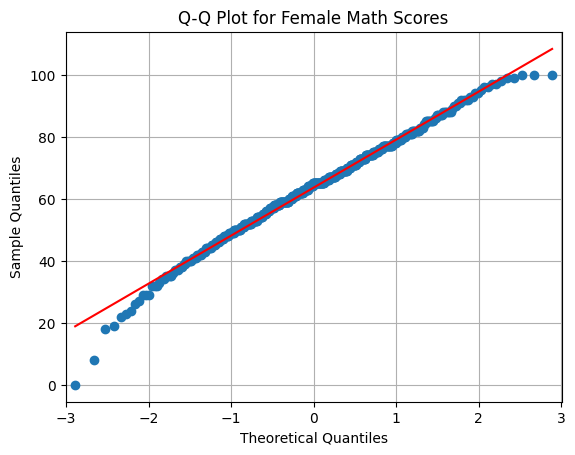

In [13]:
## TODO: Create a plot for the female math scores to check for normality.
plt.figure(figsize=(10, 8), dpi = 80)
sm.qqplot(Females_Math, line='s')
plt.title('Q-Q Plot for Female Math Scores')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(True)
plt.show()

Hypothèse nulle (H₀) : Les données suivent la distribution spécifiée.  
Hypothèse alternative (H₁) : Les données ne suivent pas la distribution


</br>
</br>
</br>

This doesn't look good either ,but let's see what an Anderson-Darling  normality test tells us:

In [14]:
## TODO: Perform the Anderson-Darling test on the female math scores to check for normality.
result = stats.anderson(Females_Math, dist='norm')

print(f"Statistic: {result.statistic}")
print(f"Critical Values: {result.critical_values}")
print(f"Significance Levels: {result.significance_level}")

if result.statistic < result.critical_values[2]:
    print("Acceptation de l'hypothèse nulle")
    print("Les données suivent une distribution normale.")
else:
    print("Rejet de l'hypothèse nulle")
    print("Les données ne suivent pas une distribution normale.")

Statistic: 0.705866358838648
Critical Values: [0.572 0.651 0.781 0.911 1.084]
Significance Levels: [15.  10.   5.   2.5  1. ]
Acceptation de l'hypothèse nulle
Les données suivent une distribution normale.


at significance level 0.05 normality assumption is checked since the p-value is 0.065.


### Let's test homoschedasticity (sample size is different for each group):

In [15]:
## TODO: Calculate the ratio of the variance between male and female math scores in both directions.
ratio_male_to_female = df[df['gender'] == 'male']['math score'].var() / df[df['gender'] == 'female']['math score'].var()
ratio_female_to_male = df[df['gender'] == 'female']['math score'].var() / df[df['gender'] == 'male']['math score'].var()

print(f"Ratio of variance between male and female math scores: {round(ratio_male_to_female,2)}")
print(f"Ratio of variance between female and male math scores: {round(ratio_female_to_male,2)}")

Ratio of variance between male and female math scores: 0.86
Ratio of variance between female and male math scores: 1.16


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [16]:
## TODO: Remove outliers from male and female math scores using the IQR method and filter them out of the dataset.
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = df[(df['math score'] >= Q1 - 1.5 * IQR) & (df['math score'] <= Q3 + 1.5 * IQR)]

Males_Math = df_no_outliers[df_no_outliers['gender'] == 'male']['math score']
Females_Math = df_no_outliers[df_no_outliers['gender'] == 'female']['math score']


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that males are better at maths than females as the alternative hypothesis

$$
H_{0} : \mu_{MaleMaths}\leq \mu_{FemaleMaths}
$$

$$
H_{A} : \mu_{MaleMaths} >  \mu_{FemaleMaths}
$$

In [17]:
## TODO: Perform a t-test to compare male and female math scores, testing if males have significantly greater scores.
t_statistic, p_value = stats.ttest_ind(Males_Math, Females_Math, alternative='greater')
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print('Rejet de l\'hypothèse nulle')
    print('There is a statistically significant difference in math scores between males and females.')
else:
    print('Acceptation de l\'hypothèse nulle')
    print('There is no statistically significant difference in math scores between males and females.')

T-statistic: 4.777915036230824
P-value: 1.0195353900174292e-06
Rejet de l'hypothèse nulle
There is a statistically significant difference in math scores between males and females.


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that males are better than females at maths is true.**



***



# Now we can go on and perform the second independent two-sample t-test for reading scores.

We take male and females groups for the reading scores:

In [18]:
## TODO: Extract the reading scores for males and females from the tidy_StudentsPerformance dataset.
Males_Reading = df[df['gender'] == 'male']['reading score']
Females_Reading = df[df['gender'] == 'female']['reading score']

print(f"Number of male students: {len(Males_Reading)}")
print(f"Number of female students: {len(Females_Reading)}")

Number of male students: 482
Number of female students: 518



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's go straight to tests.

In [19]:
## TODO: Perform the Cramer-Von Mises test on the Males_Reading scores.
res = stats.cramervonmises(Males_Reading,'norm', args=(0, 1))
print(f"Statistic: {res.statistic}")
print(f"P-value: {res.pvalue}")

if res.pvalue < 0.05:
    print("Rejet de l'hypothèse nulle")
    print("Les données ne suivent pas une distribution normale.")
else :
    print("Acceptation de l'hypothèse nulle")
    print("Les données suivent une distribution normale.")


Statistic: 160.66666666666669
P-value: 0.0
Rejet de l'hypothèse nulle
Les données ne suivent pas une distribution normale.


at significance level 0.05 normality assumption is checked since the p-value is 0.11.


### Let's check for the females group:

In [20]:
## TODO: Perform the Cramer-Von Mises test on the Females_Reading scores.
res = stats.cramervonmises(Females_Reading,'norm', args=(0, 1))
print(f"Statistic: {res.statistic}")
print(f"P-value: {res.pvalue}")

if res.pvalue < 0.05:
    print("Rejet de l'hypothèse nulle")
    print("Les données ne suivent pas une distribution normale.")
else :
    print("Acceptation de l'hypothèse nulle")
    print("Les données suivent une distribution normale.")

Statistic: 172.66666666666666
P-value: 0.0
Rejet de l'hypothèse nulle
Les données ne suivent pas une distribution normale.


at significance level 0.05 normality assumption is checked since the p-value is 0.068.


let's test homoschedasticity (sample size is different for each group):

In [21]:
## TODO: Calculate the ratio of variances between Males_Reading and Females_Reading scores.
ratio_var = df[df['gender'] == 'male']['reading score'].var() / df[df['gender'] == 'female']['reading score'].var()
print(f"Ratio of variance between male and female reading scores: {round(ratio_var,2)}")

Ratio of variance between male and female reading scores: 0.94


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [22]:
Males_Reading.head()

,reading score
3,57
4,78
7,43
8,64
10,54


In [23]:
# Remove outliers using the IQR method from Males_Reading scores
Q1_males_reading = Males_Reading.quantile(0.25)
Q3_males_reading = Males_Reading.quantile(0.75)
IQR_males_reading = Q3_males_reading - Q1_males_reading
Males_Reading_no_outliers = Males_Reading[(Males_Reading >= Q1_males_reading - 1.5 * IQR_males_reading) & (Males_Reading <= Q3_males_reading + 1.5 * IQR_males_reading)]

# Remove outliers using the IQR method from Females_Reading scores
Q1_females_reading = Females_Reading.quantile(0.25)
Q3_females_reading = Females_Reading.quantile(0.75)
IQR_females_reading = Q3_females_reading - Q1_females_reading
Females_Reading_no_outliers = Females_Reading[(Females_Reading >= Q1_females_reading - 1.5 * IQR_females_reading) & (Females_Reading <= Q3_females_reading + 1.5 * IQR_females_reading)]

print(f"Original Males_Reading count: {len(Males_Reading)}")
print(f"Males_Reading count after outlier removal: {len(Males_Reading_no_outliers)}")
print(f"Original Females_Reading count: {len(Females_Reading)}")
print(f"Females_Reading count after outlier removal: {len(Females_Reading_no_outliers)}")

Original Males_Reading count: 482
Males_Reading count after outlier removal: 479
Original Females_Reading count: 518
Females_Reading count after outlier removal: 513


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at reading than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleReading}\leq \mu_{MaleReading}$$

$$H_{A} : \mu_{FemaleReading} >  \mu_{MaleReading}$$

In [24]:
## TODO: Perform a t-test to compare Females_Reading and Males_Reading scores, testing if the mean score for females is greater.
t_statistic, p_value = stats.ttest_ind(Females_Reading_no_outliers, Males_Reading_no_outliers, alternative='greater')
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print('Rejet de l\'hypothèse nulle')
    print('There is a statistically significant difference in reading scores between males and females.')
else:
    print('Acceptation de l\'hypothèse nulle')
    print('There is no statistically significant difference in reading scores between males and females.')

T-statistic: 8.450796143741597
P-value: 5.1191849528288104e-17
Rejet de l'hypothèse nulle
There is a statistically significant difference in reading scores between males and females.


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at reading is true.**



***



# Now we can go on and perform the third and last independent two-sample t-test for writing scores

We take male and females groups for the writing scores:

In [25]:
## TODO: Create two separate dataframes, one for male and one for female writing scores.
Males_Writing = df[df['gender'] == 'male']['writing score']
Females_Writing = df[df['gender'] == 'female']['writing score']


### Now we are able to go on and check the t- test assumptions:

- Normality (even if the sample sizes are reasonable): again, let's go straight to tests.


In [26]:
## TODO: Perform the Cramer-Von Mises test for the male writing scores.
res = stats.cramervonmises(Males_Writing,'norm', args=(0, 1))
print(f"Statistic: {res.statistic}")
print(f"P-value: {res.pvalue}")

if res.pvalue < 0.05:
    print("Rejet de l'hypothèse nulle")
    print("Les données ne suivent pas une distribution normale.")
else :
    print("Acceptation de l'hypothèse nulle")
    print("Les données suivent une distribution normale.")

Statistic: 160.66666666666669
P-value: 0.0
Rejet de l'hypothèse nulle
Les données ne suivent pas une distribution normale.


at significance level 0.05 normality assumption is checked since the p-value is 0.09.


### Let's check for the females group:

In [27]:
## TODO: Perform the Lilliefors test for the female writing scores.
kstat, p_value = stats.kstest(Females_Writing,'norm')
print(f'p-value : {p_value}')
print(f'K-statistic : {kstat}')

if p_value < 0.05:
    print("Rejet de l'hypothèse nulle")
    print("Les données ne suivent pas une distribution normale.")
else:
    print("Acceptation de l'hypothèse nulle")
    print("Les données suivent une distribution normale.")


p-value : 0.0
K-statistic : 1.0
Rejet de l'hypothèse nulle
Les données ne suivent pas une distribution normale.


**It looks like the normality assumption is not verified here!**

### So let's try to transform data with box-cox transformation

In [28]:
## TODO: Perform the Box-Cox transformation and apply the CVM test to the writing scores of both males and females.

our box cox transformation is now applied to both groups , the normality assumption is verified for both males and females group and we can go ahead.



let's test homoschedasticity (sample size is different for each group):

In [29]:
## TODO: Calculate and compare the variance of writing scores for males and females.

it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.



### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at writing than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleWriting}\leq \mu_{MaleWriting}$$

$$H_{A} : \mu_{FemaleWriting} >  \mu_{MaleWriting}$$

In [30]:
## TODO: Perform a t-test to compare Box-Cox transformed writing scores for males and females with the alternative hypothesis "greater".

Again , the p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at writing is true.**



***

# XP NINJA

# One-way ANOVA

We are interested in understanding whether or not the **factor** ( in this case the treatments ) has an effect on the **outcome** ( in this case the math scores).

The treatments factor is structured in four different levels:

- **Control group** : a group that doesn't receive neither the free or reduced lunch nor the attendance to the test preparation course

- **Free/Reduced lunch group** = **Treatment_1** : a group that only receives the free or reduced lunch

- **Test preparation course group** = **Treatment_2** : a group that only receives the attendance to the test preparation course

- **Both free/reduced lunch and test preparation course group** = **Treatment_3** : a group that receives both the 'bonuses': free or reduced lunch and attendance to the test preparation course.



### For ANOVA we will have the following hypothesis:

$$H_{0} : The \:means\:of\:different\:groups\:is\:the\:same$$

$$H_{A} : At\:least\:one\:sample\:mean\:is\:not\:equal\:to\:others$$


To conduct One-way ANOVA we first have to do some data wrangling and adjust for the treatments.

In [31]:
## TODO: Filter and create groups for analysis based on various criteria (lunch type and test preparation status).

# Control group


# Free/Reduced lunch group


# Test preparation course group


# Both free/reduced lunch and test preparation course group


# Bind everything together




### Now we go along and check the assumptions:

- Normality Assumption: let's check the situation visually first

In [32]:
## TODO: Create a density plot to compare the scores by treatment type.

</br>
</br>
</br>

Each group looks pretty normal , but let's perform some tests to be sure:


In [33]:
## TODO: Perform normality tests for each group using Shapiro-Wilk and Lilliefors tests.

**Normality is checked for each treatment group!**

- Similarity of variances

In [34]:
## TODO: Check for the similarity of variances using rough rules and perform Bartlett's and Fligner tests.

**Homogeneity of variances of treatment groups is checked!** ( both with a rough rule and with actual tests.)

We can finally perform ANOVA:

In [35]:
## TODO: Perform ANOVA to check if there's a significant difference between the groups.

### Key takeaways:


- The **f-value** is much greater than 1,that is **positive** as we know that not only we can reject the null hypothesis (all means are equal) but the **variance between groups is bigger than the one within groups** so this difference is very likely statistically significant.

- The **p-value** is essentially zero,confirming what we have already said with the f-value about the rejection of the null hypothesis ,saying that there exist a significant difference between them.


### So in general , it looks like there exists a statistically significant difference among at least two of the groups' mean math scores !

But wait... which couples of means are different from each other?

To answer this question we must perform a post-hoc test.

### Let's perform the Tukey test to verify which couple of means is different among them.

### Key takeaways:

- As the boxplot already showed , the difference in means between treatment 1 and control , with control group having higher math scores , is significant: **it looks like having the economic freedom of not paying or paying less for lunch negatively impats math scores!**

- Another important difference already present in the boxplot , the difference in means between treatment 2 and 1 , with treatment 2 having higher math scores , is significant:  **only attending the test preparation course and not having the economic freedom of the free or reduced lunch is more effective than having that economic freedom and not attending the test preparation course!**

- This difference was also present in the boxplot , like the other two , and is between the third and second treatments, with treatment two being more effective than the third.
This means that : **the people who attended the test preparation course but also enjoyed the economic freedom of the free/reduced lunch , statistically perform worse than people who have attened the test , but have to pay for lunch**.

### Conclusions : from these tests it looks like , while on the one hand saving the lunch money has a negative effect on math scores as opposed as we expected , on the other hand attending the test preparation course has a positive one as we expected.

### Maybe people used the money saved from lunch to buy things that distracted them from studying maths! That's not good , buy more math books with that money!



